In [1]:
import torch as tc
import numpy as np
import matplotlib.pyplot as plt
from fun import Rede,SIN
from tqdm import tqdm
import math

In [2]:
tfinal = 2.1
N      = 100
Nedo   = 25
Nfield = 0

In [3]:
neuronio = [50,50]

X_vector   = Rede(
    neuronio    = neuronio,
    input_      = 1,
    output_     = Nedo+Nfield,
    activation  =[tc.nn.Tanh()]*len(neuronio))

opt = tc.optim.Adam(X_vector.parameters(),
        lr = 0.001)
time =  tc.linspace(
        0,
        tfinal,
        N,
        dtype   = tc.float32,
        requires_grad = True).reshape((-1, 1))

100%|██████████| 10000/10000 [01:30<00:00, 109.96it/s]


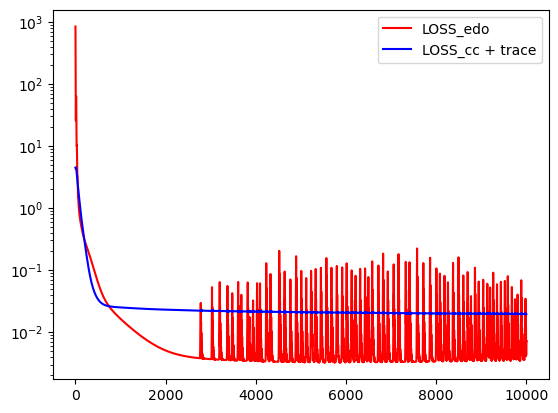

In [4]:

# =========================
# Parâmetros
# =========================
epocas = 10000
factor_time = 1.0

fq   = 5.0 * factor_time
wt0  = 1.0 * factor_time
alfa = -0.3 * factor_time   # mesmo sinal que você já vinha usando

sqrt2 = 1.4142135623730951
sqrt3 = 1.7320508075688772
sqrt6 = 2.4494897427831781

LOSS = []
LOSS1 = []
LOSS2 = []

# ==========================================================
# Convenção das 25 saídas da rede
# ==========================================================
#  0 : rho00
#  1 : rho11
#  2 : rho22
#  3 : rho33
#  4 : rho44
#
#  5 : Re(rho01)   6 : Im(rho01)
#  7 : Re(rho02)   8 : Im(rho02)
#  9 : Re(rho03)  10 : Im(rho03)
# 11 : Re(rho04)  12 : Im(rho04)
# 13 : Re(rho12)  14 : Im(rho12)
# 15 : Re(rho13)  16 : Im(rho13)
# 17 : Re(rho14)  18 : Im(rho14)
# 19 : Re(rho23)  20 : Im(rho23)
# 21 : Re(rho24)  22 : Im(rho24)
# 23 : Re(rho34)  24 : Im(rho34)

for ep in tqdm(range(epocas)):
    # =====================================
    # Forward
    # =====================================
    y = X_vector(time)   # saída da rede: [len(time), 25]

    # derivadas temporais
    term1 = []
    for i in range(y.shape[1]):
        dy_dt = tc.autograd.grad(
            outputs=y[:, i],
            inputs=time,
            grad_outputs=tc.ones_like(y[:, i]),
            create_graph=True
        )[0]
        term1.append(dy_dt)
    term1 = tc.cat(term1, dim=1)

    # =====================================
    # Desempacotando variáveis
    # =====================================
    rho00 = y[:, 0:1]
    rho11 = y[:, 1:2]
    rho22 = y[:, 2:3]
    rho33 = y[:, 3:4]
    rho44 = y[:, 4:5]

    a01 = y[:, 5:6];  b01 = y[:, 6:7]
    a02 = y[:, 7:8];  b02 = y[:, 8:9]
    a03 = y[:, 9:10]; b03 = y[:, 10:11]
    a04 = y[:, 11:12]; b04 = y[:, 12:13]
    a12 = y[:, 13:14]; b12 = y[:, 14:15]
    a13 = y[:, 15:16]; b13 = y[:, 16:17]
    a14 = y[:, 17:18]; b14 = y[:, 18:19]
    a23 = y[:, 19:20]; b23 = y[:, 20:21]
    a24 = y[:, 21:22]; b24 = y[:, 22:23]
    a34 = y[:, 23:24]; b34 = y[:, 24:25]

    wt = wt0 * tc.ones_like(rho00)

    # ==========================================================
    # Equações diferenciais
    # Usando: rho_ij = aij + i bij
    # e as equações que escrevi antes para dot(rho_ij)
    # ==========================================================

    # -------------------------
    # Populações
    # -------------------------
    # dot(rho00) = i[ wt(r01-r10) - 6sqrt2 a (r02-r20) - 2sqrt6 a (r04-r40) ]
    # como r01-r10 = 2i Im(r01), etc:
    f_rho00 = -2*wt*b01 + 12*sqrt2*alfa*b02 + 4*sqrt6*alfa*b04

    f_rho11 =  2*wt*b01 - 2*sqrt2*wt*b12 + 20*sqrt6*alfa*b13

    f_rho22 = -12*sqrt2*alfa*b02 + 2*sqrt2*wt*b12 - 2*sqrt3*wt*b23 + 36*sqrt3*alfa*b24

    f_rho33 = -20*sqrt6*alfa*b13 + 2*sqrt3*wt*b23 - 4*wt*b34

    f_rho44 = -4*sqrt6*alfa*b04 - 36*sqrt3*alfa*b24 + 4*wt*b34

    # -------------------------
    # Coerência rho01 = a01 + i b01
    # dot(rho01) = i * S01
    # Se S01 = A + iB, então dot(a01) = -B, dot(b01) = A
    # -------------------------
    S01_re = ((fq - 12*alfa)*a01
              + wt*(rho00 - rho11)
              + sqrt2*wt*a02
              - 10*sqrt6*alfa*a03
              + 6*sqrt2*alfa*a12
              + 2*sqrt6*alfa*a14)

    S01_im = ((fq - 12*alfa)*b01
              + sqrt2*wt*b02
              - 10*sqrt6*alfa*b03
              + 6*sqrt2*alfa*b12
              + 2*sqrt6*alfa*b14)

    f_a01 = -S01_im
    f_b01 =  S01_re

    # -------------------------
    # rho02
    # -------------------------
    S02_re = ((2*fq - 36*alfa)*a02
              - 6*sqrt2*alfa*(rho00 - rho22)
              + sqrt2*wt*a01
              + sqrt3*wt*a03
              - wt*a12
              - 18*sqrt3*alfa*a04
              + 2*sqrt6*alfa*a24)

    S02_im = ((2*fq - 36*alfa)*b02
              + sqrt2*wt*b01
              + sqrt3*wt*b03
              - wt*b12
              - 18*sqrt3*alfa*b04
              + 2*sqrt6*alfa*b24)

    f_a02 = -S02_im
    f_b02 =  S02_re

    # -------------------------
    # rho03
    # -------------------------
    S03_re = ((3*fq - 52*alfa)*a03
              - 10*sqrt6*alfa*a01
              + sqrt3*wt*a02
              + 2*wt*a04
              - wt*a13
              + 6*sqrt2*alfa*a23
              + 2*sqrt6*alfa*a34)

    S03_im = ((3*fq - 52*alfa)*b03
              - 10*sqrt6*alfa*b01
              + sqrt3*wt*b02
              + 2*wt*b04
              - wt*b13
              + 6*sqrt2*alfa*b23
              + 2*sqrt6*alfa*b34)

    f_a03 = -S03_im
    f_b03 =  S03_re

    # -------------------------
    # rho04
    # -------------------------
    S04_re = ((4*fq - 25*alfa)*a04
              - 2*sqrt6*alfa*(rho00 - rho44)
              - 18*sqrt3*alfa*a02
              + 2*wt*a03
              - wt*a14
              + 6*sqrt2*alfa*a24)

    S04_im = ((4*fq - 25*alfa)*b04
              - 18*sqrt3*alfa*b02
              + 2*wt*b03
              - wt*b14
              + 6*sqrt2*alfa*b24)

    f_a04 = -S04_im
    f_b04 =  S04_re

    # -------------------------
    # rho12
    # -------------------------
    S12_re = ((fq - 24*alfa)*a12
              - 6*sqrt2*alfa*a01
              + sqrt2*wt*(rho11 - rho22)
              + sqrt3*wt*a13
              - wt*a02
              - 18*sqrt3*alfa*a14
              + 10*sqrt6*alfa*a23)

    S12_im = ((fq - 24*alfa)*b12
              + 6*sqrt2*alfa*b01
              + sqrt3*wt*b13
              - wt*b02
              - 18*sqrt3*alfa*b14
              + 10*sqrt6*alfa*b23)

    f_a12 = -S12_im
    f_b12 =  S12_re

    # -------------------------
    # rho13
    # -------------------------
    S13_re = ((2*fq - 40*alfa)*a13
              - 10*sqrt6*alfa*(rho11 - rho33)
              - wt*a03
              + sqrt3*wt*a12
              + 2*wt*a14
              - sqrt2*wt*a23)

    S13_im = ((2*fq - 40*alfa)*b13
              - wt*b03
              + sqrt3*wt*b12
              + 2*wt*b14
              - sqrt2*wt*b23)

    f_a13 = -S13_im
    f_b13 =  S13_re

    # -------------------------
    # rho14
    # -------------------------
    S14_re = ((3*fq - 13*alfa)*a14
              - 2*sqrt6*alfa*a01
              - 18*sqrt3*alfa*a12
              - wt*a04
              + 2*wt*a13
              - sqrt2*wt*a24
              + 10*sqrt6*alfa*a34)

    S14_im = ((3*fq - 13*alfa)*b14
              + 2*sqrt6*alfa*b01
              - 18*sqrt3*alfa*b12
              - wt*b04
              + 2*wt*b13
              - sqrt2*wt*b24
              + 10*sqrt6*alfa*b34)

    f_a14 = -S14_im
    f_b14 =  S14_re

    # -------------------------
    # rho23
    # -------------------------
    S23_re = ((fq - 16*alfa)*a23
              + 6*sqrt2*alfa*a03
              - 10*sqrt6*alfa*a12
              + sqrt3*wt*(rho22 - rho33)
              - sqrt2*wt*a13
              + 2*wt*a24
              + 18*sqrt3*alfa*a34)

    S23_im = ((fq - 16*alfa)*b23
              + 6*sqrt2*alfa*b03
              - 10*sqrt6*alfa*b12
              - sqrt2*wt*b13
              + 2*wt*b24
              + 18*sqrt3*alfa*b34)

    f_a23 = -S23_im
    f_b23 =  S23_re

    # -------------------------
    # rho24
    # -------------------------
    S24_re = ((2*fq + 11*alfa)*a24
              + 6*sqrt2*alfa*a04
              - 2*sqrt6*alfa*a02
              - 18*sqrt3*alfa*(rho22 - rho44)
              - sqrt2*wt*a14
              + 2*wt*a23
              - sqrt3*wt*a34)

    S24_im = ((2*fq + 11*alfa)*b24
              + 6*sqrt2*alfa*b04
              + 2*sqrt6*alfa*b02
              - sqrt2*wt*b14
              + 2*wt*b23
              - sqrt3*wt*b34)

    f_a24 = -S24_im
    f_b24 =  S24_re

    # -------------------------
    # rho34
    # -------------------------
    S34_re = ((fq + 27*alfa)*a34
              + 10*sqrt6*alfa*a14
              - 2*sqrt6*alfa*a03
              - 18*sqrt3*alfa*a23
              + 2*wt*(rho33 - rho44)
              - sqrt3*wt*a24)

    S34_im = ((fq + 27*alfa)*b34
              + 10*sqrt6*alfa*b14
              + 2*sqrt6*alfa*b03
              - 18*sqrt3*alfa*b23
              - sqrt3*wt*b24)

    f_a34 = -S34_im
    f_b34 =  S34_re

    # =====================================
    # LOSS EDO
    # =====================================
    LOSS_edo = (term1[:, 0:1] - f_rho00)**2
    LOSS_edo += (term1[:, 1:2] - f_rho11)**2
    LOSS_edo += (term1[:, 2:3] - f_rho22)**2
    LOSS_edo += (term1[:, 3:4] - f_rho33)**2
    LOSS_edo += (term1[:, 4:5] - f_rho44)**2

    LOSS_edo += (term1[:, 5:6]  - f_a01)**2
    LOSS_edo += (term1[:, 6:7]  - f_b01)**2
    LOSS_edo += (term1[:, 7:8]  - f_a02)**2
    LOSS_edo += (term1[:, 8:9]  - f_b02)**2
    LOSS_edo += (term1[:, 9:10] - f_a03)**2
    LOSS_edo += (term1[:, 10:11] - f_b03)**2
    LOSS_edo += (term1[:, 11:12] - f_a04)**2
    LOSS_edo += (term1[:, 12:13] - f_b04)**2
    LOSS_edo += (term1[:, 13:14] - f_a12)**2
    LOSS_edo += (term1[:, 14:15] - f_b12)**2
    LOSS_edo += (term1[:, 15:16] - f_a13)**2
    LOSS_edo += (term1[:, 16:17] - f_b13)**2
    LOSS_edo += (term1[:, 17:18] - f_a14)**2
    LOSS_edo += (term1[:, 18:19] - f_b14)**2
    LOSS_edo += (term1[:, 19:20] - f_a23)**2
    LOSS_edo += (term1[:, 20:21] - f_b23)**2
    LOSS_edo += (term1[:, 21:22] - f_a24)**2
    LOSS_edo += (term1[:, 22:23] - f_b24)**2
    LOSS_edo += (term1[:, 23:24] - f_a34)**2
    LOSS_edo += (term1[:, 24:25] - f_b34)**2

    LOSS_edo = LOSS_edo.mean()

    # =====================================
    # Condição inicial: |psi(0)> = |0>
    # rho(0) = |0><0|
    # =====================================
    LOSS_cc = (rho00[0] - 1.0)**2
    LOSS_cc += (rho11[0] - 0.0)**2
    LOSS_cc += (rho22[0] - 0.0)**2
    LOSS_cc += (rho33[0] - 0.0)**2
    LOSS_cc += (rho44[0] - 0.0)**2

    LOSS_cc += (a01[0] - 0.0)**2 + (b01[0] - 0.0)**2
    LOSS_cc += (a02[0] - 0.0)**2 + (b02[0] - 0.0)**2
    LOSS_cc += (a03[0] - 0.0)**2 + (b03[0] - 0.0)**2
    LOSS_cc += (a04[0] - 0.0)**2 + (b04[0] - 0.0)**2
    LOSS_cc += (a12[0] - 0.0)**2 + (b12[0] - 0.0)**2
    LOSS_cc += (a13[0] - 0.0)**2 + (b13[0] - 0.0)**2
    LOSS_cc += (a14[0] - 0.0)**2 + (b14[0] - 0.0)**2
    LOSS_cc += (a23[0] - 0.0)**2 + (b23[0] - 0.0)**2
    LOSS_cc += (a24[0] - 0.0)**2 + (b24[0] - 0.0)**2
    LOSS_cc += (a34[0] - 0.0)**2 + (b34[0] - 0.0)**2

    LOSS_cc = LOSS_cc.mean()

    # opcional: conservação de traço
    LOSS_trace = ((rho00 + rho11 + rho22 + rho33 + rho44) - 1.0)**2
    LOSS_trace = LOSS_trace.mean()

    # =====================================
    # Loss total
    # =====================================
    loss_i = LOSS_edo + LOSS_cc + LOSS_trace

    # =====================================
    # Backprop
    # =====================================
    opt.zero_grad()
    loss_i.backward()
    opt.step()

    LOSS.append(loss_i.detach().cpu().numpy())
    LOSS1.append(LOSS_edo.detach().cpu().numpy())
    LOSS2.append((LOSS_cc + LOSS_trace).detach().cpu().numpy())

# =====================================
# Plot
# =====================================
plt.plot(LOSS1, 'r-', label='LOSS_edo')
plt.plot(LOSS2, 'b-', label='LOSS_cc + trace')
plt.yscale('log')
plt.legend()
plt.show()

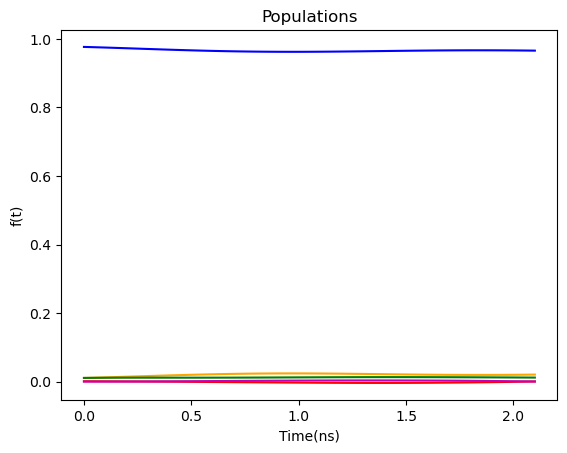

In [5]:
t_points =  np.linspace(0,tfinal, N)
X_  = X_vector(time).detach().numpy()
# w_opt=(1-np.exp(-t_points))*(X_[:,1])
# w_opt=np.sin(np.pi/2*t_points)**2*(X_[:,6])

plt.plot(t_points,X_[:,0],"b")
plt.plot(t_points,X_[:,1],"orange")
plt.plot(t_points,X_[:,2],"g")
plt.plot(t_points,X_[:,3],"r")
plt.plot(t_points,X_[:,4],"m")

# plt.plot(t_points,(X_[:,0])**2+(X_[:,5])**2,"b")
# plt.plot(t_points,(X_[:,1])**2+(X_[:,6])**2,"orange")
# plt.plot(t_points,(X_[:,2])**2+(X_[:,7])**2,"g")
# plt.plot(t_points,(X_[:,3])**2+(X_[:,8])**2,"r")
# plt.plot(t_points,(X_[:,4])**2+(X_[:,9])**2,"m")
plt.xlabel('Time(ns)')
plt.ylabel('f(t)')
plt.title('Populations')
plt.show()


/home/gubio/anaconda3/lib/python3.13/site-packages/qutip/solver/solver_base.py:583: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


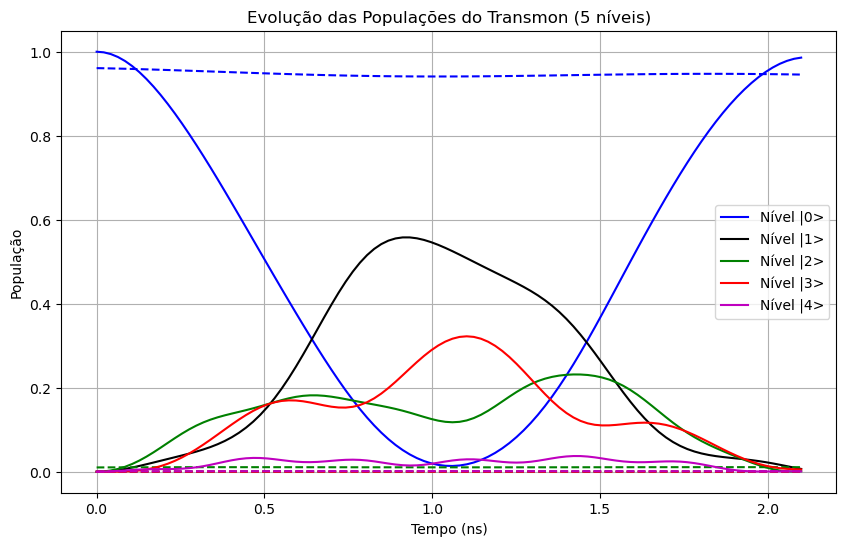

In [6]:
import qutip as qt
from qutip import destroy, hinton, basis, mesolve, qeye

def simulate_transmon(t_points):
    # Parâmetros do Transmon (em unidades de GHz, por exemplo)
    N = 5  # Número de níveis
    f_q = 5.0  # Frequência do qubit (0 -> 1) em GHz
    alpha = -0.3  # Anarmonicidade em GHz (típico para transmons)

    # Operadores
    a = destroy(N)
    adag = a.dag()

    # Hamiltoniano do Transmon (Duffing Oscillator)
    # H = f_q * a.dag() * a + (alpha/2) * a.dag() * a.dag() * a * a
    H0 = f_q * adag * a + (alpha / 2.0)*(a.dag() +a)*(a.dag() +a)*(a.dag() +a)*(a.dag() +a) #

    # 1. Calcular Níveis de Energia
    energies = H0.eigenenergies()
    # print("Níveis de Energia (GHz):")
    # for i, E in enumerate(energies):
    #     print(f"Nível {i}: {E:.4f} GHz")

    # 2. Simulação de Evolução Temporal (Rabi Oscillation)
    # Vamos aplicar um drive ressonante com a transição 0 -> 1
    Omega = 1.0  # Força do drive (Rabi frequency) em GHz
    H_drive = Omega * (a + adag)

    # Hamiltoniano total
    # H = [H0, [H_drive, w0]]
    H = H0+H_drive
    args = {'wd': f_q}

    # Estado inicial: fundamental |0>
    psi0 = basis(N, 0)

    # Tempos de simulação
    tlist =t_points


    # Resolver a equação de mestre (sem dissipação por enquanto)
    result = mesolve(H, psi0, tlist, [], [basis(N, i) * basis(N, i).dag() for i in range(N)], args=args)

    # Plotar as populações
    plt.figure(figsize=(10, 6))
    plt.plot(tlist,result.expect[0],"b", label=f'Nível |{0}>')
    plt.plot(tlist,
             (X_[:,0])**2 + (X_[:,5])**2,"b--")
    
    plt.plot(tlist, result.expect[1],"k", label=f'Nível |{1}>')
    plt.plot(t_points,
             (X_[:,1])**2 + (X_[:,6])**2,
             "k--")
    
    plt.plot(tlist, result.expect[2],"g", label=f'Nível |{2}>')
    plt.plot(t_points,
             (X_[:,2])**2 + (X_[:,7])**2,
             "g--")
    
    plt.plot(tlist, result.expect[3],"r", label=f'Nível |{3}>')
    plt.plot(t_points,
             (X_[:,3])**2 + (X_[:,8])**2,"r--")
    
    plt.plot(tlist, result.expect[4],"m", label=f'Nível |{4}>')
    plt.plot(t_points,
             (X_[:,4])**2 + (X_[:,9])**2,"m--")
    
    plt.title('Evolução das Populações do Transmon (5 níveis)')
    plt.xlabel('Tempo (ns)')
    plt.ylabel('População')
    plt.legend()
    plt.grid(True)
    plt.show()
    # plt.savefig('transmon_populations.png')
    # print("Gráfico de populações salvo como 'transmon_populations.png'")

simulate_transmon(t_points)
